# Reaction time

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [ ]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    

Using notebook 3d backend.


In [ ]:
ref = 'bipolar'
tasks = ['LexicalDelay', 'PhonemeSequence']

rt = []

for task in tasks:
    result_path = BIDSPath(
        datatype='RT',
        root=f'../results/{task}({ref})',
        suffix='highgamma',
        check=False
    )

    full_path = result_path.match()
    if not full_path:
        print(f'No RT results found for {task}, skipping.')
        continue

    for path in tqdm(full_path, desc=task):
        mat = h5py.File(path, 'r')
        
        # r2: (channels, time)
        r2 = mat['score'][()]
        
        pearsonr = mat['score'][()]
        # time: (time,)
        time = mat['time'][()]
        # channels: (channels,)
        channels = [ch.decode('utf-8') for ch in mat['channels'][:]]
        # pval: (channels, time)
        pval = mat['pval'][()]
        # perm_r2: (channels, time, n_perm)
        perm_r2 = mat['perm_r2'][()]
        # cluster_pval: (channels, time)
        cluster_pval = mat['cluster_pval'][()]
        # mask: (channels, time)
        mask = mat['mask'][()]
        
        mat.close()
        
        n_channels, n_time = r2.shape
        
        # ---- 1) perm_r2 在 perm 维度上平均 → (channels, time) ----
        perm_r2_mean = perm_r2.mean(axis=-1)  # shape: (channels, time)
        
        # ---- 2) 宽表：每列一个 time point（r2）----
        df_r2 = pd.DataFrame(r2, index=channels, columns=time).reset_index()
        df_r2 = df_r2.rename(columns={'index': 'channel'})
        
        # 宽表 perm_r2_mean
        df_perm = pd.DataFrame(perm_r2_mean, index=channels, columns=time).reset_index()
        df_perm = df_perm.rename(columns={'index': 'channel'})
        
        # 宽表 pval
        df_pval = pd.DataFrame(pval, index=channels, columns=time).reset_index()
        df_pval = df_pval.rename(columns={'index': 'channel'})
        
        # 宽表 cluster_pval
        df_cluster_pval = pd.DataFrame(cluster_pval, index=channels, columns=time).reset_index()
        df_cluster_pval = df_cluster_pval.rename(columns={'index': 'channel'})
        
        # 宽表 mask
        df_mask = pd.DataFrame(mask, index=channels, columns=time).reset_index()
        df_mask = df_mask.rename(columns={'index': 'channel'})
        
        # ---- 3) 宽 → 长，显式保留 channel ----
        df_r2 = df_r2.melt(id_vars='channel', var_name='time', value_name='r2')
        df_perm = df_perm.melt(id_vars='channel', var_name='time', value_name='perm_r2_mean')
        df_pval = df_pval.melt(id_vars='channel', var_name='time', value_name='pval')
        df_cluster_pval = df_cluster_pval.melt(id_vars='channel', var_name='time', value_name='cluster_pval')
        df_mask = df_mask.melt(id_vars='channel', var_name='time', value_name='mask')
        
        # 合并所有指标（按 channel, time 对齐）
        df = df_r2.merge(df_perm, on=['channel', 'time'], how='left')
        df = df.merge(df_pval, on=['channel', 'time'], how='left')
        df = df.merge(df_cluster_pval, on=['channel', 'time'], how='left')
        df = df.merge(df_mask, on=['channel', 'time'], how='left')
        
        # ---- 4) 加上 path 的元信息 ----
        df['subject'] = path.subject
        df['phase'] = path.processing
        df['description'] = path.description
        df['band'] = path.suffix
        df['task'] = task
        
        rt.append(df)

rt = pd.concat(rt, ignore_index=True)
print(f'Total rows: {len(rt):,}')
print(f'Tasks: {rt.task.unique().tolist()}')
print(f'Subjects per task:')
print(rt.groupby('task')['subject'].nunique())
rt.head()

PhonemeSequence: 100%|██████████| 180/180 [00:07<00:00, 24.64it/s]


Total rows: 1,570,756
Tasks: ['LexicalDelay', 'PhonemeSequence']
Subjects per task:
task
LexicalDelay       40
PhonemeSequence    45
Name: subject, dtype: int64


,channel,time,r2,perm_r2_mean,pval,cluster_pval,mask,subject,phase,description,band,task
0,D0023_RMSF9-10,-0.8,0.088125,-0.005343,0.209581,0.209581,False,D0023,Delay,Decision,highgamma,LexicalDelay
1,D0023_RMSF10-11,-0.8,-0.100959,0.001421,0.872255,0.872255,False,D0023,Delay,Decision,highgamma,LexicalDelay
2,D0023_RPSF1-2,-0.8,-0.182163,-0.004423,0.978044,0.978044,False,D0023,Delay,Decision,highgamma,LexicalDelay
3,D0023_RPSF5-6,-0.8,-0.072658,-0.004403,0.788423,0.788423,False,D0023,Delay,Decision,highgamma,LexicalDelay
4,D0023_RPSF8-9,-0.8,0.184029,0.005443,0.019960,0.019960,False,D0023,Delay,Decision,highgamma,LexicalDelay


In [ ]:
# load zscore to get electrode coordinates
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        # 'LexicalNoDelay',
        'LexicalDelay',
        # 'PictureNaming',
        # 'SentenceRep'
        ]

ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'

HGAs.head()

100%|██████████| 738/738 [00:06<00:00, 110.46it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


In [ ]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 219520
PIC electrode count: 184960


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


In [ ]:
# 先转成数值时间
rt['time'] = pd.to_numeric(rt['time'], errors='coerce')

# 仅保留在 Delay 且 0–0.5s 内显著的电极
delay_mask = (
    (rt['phase'] == 'Delay') &
    (rt['time'] >= 0.0) &
    (rt['time'] <= 0.5) &
    (rt['mask'] == True)
)
 
# Go 窗口 [-0.5, 0]
go_mask = (
    (rt['phase'] == 'Go') &
    (rt['time'] >= -0.5) &
    (rt['time'] <= 0.0) &
    (rt['mask'] == True)
)

sig_channels = np.union1d(
    rt.loc[delay_mask, 'channel'].unique(),
    rt.loc[go_mask, 'channel'].unique()
)

coords = (
    HGAs[['channel', 'roi', 'label', 'hemi', 'x', 'y', 'z']]
    .drop_duplicates()
    .reset_index(drop=True)
)

# rt = rt.merge(coords, on='channel', how='left')
rt_subset = rt[rt.channel.isin(sig_channels)]
rt_subset = rt_subset.merge(coords, on='channel', how='left')

## By Tasks

In [ ]:
# Stimulus only
phase = 'Delay'
roi = 'PIC'

subset = rt_subset[(rt_subset.phase == phase) & (rt_subset.roi == roi)].copy()
subset['time'] = pd.to_numeric(subset['time'], errors='coerce')

subset = subset[(subset.time>0) & (subset.time<1)]

# 0) 先加 R² 动态范围筛选：min>=-1, max<=1, max>0
g = subset.groupby('channel')['r2']
valid_channels = (
    g.min().ge(-1) &
    g.max().le(1) &
    g.max().gt(0)
)
valid_channels = valid_channels[valid_channels].index
subset = subset[subset['channel'].isin(valid_channels)].copy()

# 1) 再保留该 phase/roi 内至少有一个显著点的电极
sig_channels = subset.groupby('channel')['mask'].any()
sig_channels = sig_channels[sig_channels].index
stim_sig = subset[subset['channel'].isin(sig_channels)].copy()

# 2) 按每个电极第一次 mask=True 的时间排序
first_mask_time = (
    stim_sig[stim_sig['mask']]
    .groupby('channel')['time']
    .min()
    .sort_values()
)
channel_order = first_mask_time.index.tolist()

# 3) 生成按排序后的 mask 矩阵
x = (
    stim_sig
    .pivot_table(index='channel', columns='time', values='mask', aggfunc='any')
    .reindex(channel_order)
    .fillna(False)
)

print('number of significant channels: ', len(channel_order))

fig, ax = plt.subplots(figsize=(6, 0.2 * len(x.index)))
ax.pcolormesh(x.columns, np.arange(len(x.index)), x.values)
ax.set_xlabel('Time')
ax.set_ylabel('channel (sorted by first significant time)')
ax.set_yticks(np.arange(len(x.index)) + 0.5)
ax.set_yticklabels(x.index, fontsize=6)
ax.axvline(x=0, color='k', linestyle='--', linewidth=0.8)
plt.tight_layout()

NameError: name 'rt_subset' is not defined

<Figure size 640x480 with 0 Axes>

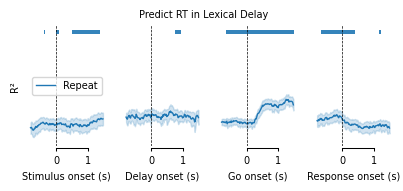

In [ ]:
sig = rt_subset[rt_subset['mask'] == True].copy()

sig = sig[sig.task=='PhonemeSequence']
# 按 channel 分组，检查每个 channel 是否至少有一个显著时间点 (mask == True)
sig_channels = sig.groupby('channel').size() > 0
sig_channels = sig_channels[sig_channels].index.tolist()

sig_rt = rt_subset[
    rt_subset['channel'].isin(sig_channels)
].copy()

# condition = ['Decision', 'Repeat']
condition = ['Repeat']

subset = sig_rt[(sig_rt.description.isin(condition))]

plt.subplots_adjust(wspace=0)

ymax, pad, bar_h = 0.1, 0.01, 0.01
sig_threshold = 0.03  # 1%

phases = ['Stimulus', 'Delay', 'Go', 'Response']

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*len(phases)*cm, 4*cm))

for (ax, phase) in zip(axes, phases):
    
    # only add the legend to the first axis
    legend = False if ax != fig.axes[0] else True

    g = subset[(subset.phase == phase)].groupby('channel')['r2']

    picks = (
        g.min().ge(-1) &   
        g.max().le(1) &    
        g.max().gt(0)     
    )
    
    picks = picks[picks].index
    palette = dict(zip(condition, sns.color_palette(n_colors=len(condition))))

    line = sns.lineplot(
        data=subset[(subset.phase == phase) & (subset.channel.isin(picks))],
        x='time',
        y='r2',
        ax=ax,
        hue='description',
        legend=legend,
        color=red,
        lw=1
    )

    ylabel = 'R²' if ax == axes[0] else ''
    ax.set_ylabel(ylabel, fontsize=7)
    ax.set_xlabel(f'{phase} onset (s)', fontsize=7)   
        
    ymin = -0.15
    bar_base = ymax + pad
    gap = bar_h * 0.1 
    
    for i, desc in enumerate(condition):
        sig_ratio = subset[(subset.phase == phase) & (subset.description == desc)].sort_values('time')
        sig_ratio = sig_ratio.groupby('time')['mask'].mean()
        aggregated_mask = sig_ratio >= sig_threshold
            
        if aggregated_mask.any():
            y0 = bar_base + i * (bar_h + gap)
            ax.fill_between(
                sig_ratio.index.values,
                y0,
                y0 + bar_h,
                where=aggregated_mask.values,
                color=palette[desc],
                alpha=0.9,
                step='mid',
                linewidth=0
            )
        
    # 让 ylim 包含所有 bar
    ax.set_ylim(ymin, bar_base + len(condition) * (bar_h + gap) + bar_h)

for ax in fig.axes:
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    # ax.axhline(y=-0.1, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    # ax.set_ylim(ymin, ymax + pad + bar_h + 0.02)

plt.suptitle(f'Predict RT in Lexical Delay', fontsize=7)
# plt.savefig(f'../img/misc/fig5_predict_rt_temporal.svg', dpi=300, bbox_inches='tight')
plt.show()

## All channel

<Figure size 640x480 with 0 Axes>

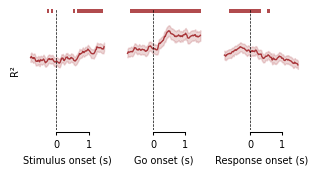

In [ ]:
sig = rt[rt['mask'] == True].copy()

# 按 channel 分组，检查每个 channel 是否至少有一个显著时间点 (mask == True)
sig_channels = sig.groupby('channel').size() > 0
sig_channels = sig_channels[sig_channels].index.tolist()

sig_rt = rt[
    rt['channel'].isin(sig_channels)
].copy()

condition = 'Repeat'
subset = sig_rt[(sig_rt.description==condition)]

plt.subplots_adjust(wspace=0)

ymax, pad, bar_h = 0.1, 0.01, 0.01
sig_threshold = 0.06  # 1%

phases = ['Stimulus', 'Go', 'Response']

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*len(phases)*cm, 4*cm))

for (ax, phase) in zip(axes, phases):
    
    # only add the legend to the first axis
    legend = False if ax != fig.axes[0] else True

    g = subset[(subset.phase == phase)].groupby('channel')['r2']

    picks = (
        g.min().ge(-1) &   
        g.max().le(1) &    
        g.max().gt(0)     
    )
    
    picks = picks[picks].index
    # palette = dict(zip(rois, sns.color_palette(n_colors=len(rois))))

    line = sns.lineplot(
        data=subset[(subset.phase == phase) & (subset.channel.isin(picks))],
        x='time',
        y='r2',
        ax=ax,
        legend=legend,
        color=red,
        lw=1
    )

    ylabel = 'R²' if ax == axes[0] else ''
    ax.set_ylabel(ylabel, fontsize=7)
    ax.set_xlabel(f'{phase} onset (s)', fontsize=7)   
        
    ymin = -0.15
    bar_base = ymax + pad
    gap = bar_h * 0.1 
    
    sig_ratio = subset[(subset.phase == phase)].sort_values('time')
    sig_ratio = sig_ratio.groupby('time')['mask'].mean()
    aggregated_mask = sig_ratio >= sig_threshold

    if aggregated_mask.any():
        y0 = bar_base + 1 * (bar_h + gap)
        ax.fill_between(
            sig_ratio.index.values,
            y0,
            y0 + bar_h,
            where=aggregated_mask.values,
            color=red,
            alpha=0.9,
            step='mid',
            linewidth=0
        )
    
    # 让 ylim 包含所有 bar
    ax.set_ylim(ymin, bar_base + 1 * (bar_h + gap) + bar_h)

for ax in fig.axes:
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    # ax.axhline(y=-0.1, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    # ax.set_ylim(ymin, ymax + pad + bar_h + 0.02)

# plt.suptitle(f'Predict RT in Lexical Delay', fontsize=7)
# plt.savefig(f'../img/misc/fig4_predict_rt_temporal.svg', dpi=300, bbox_inches='tight')
plt.show()

## Pick some roi

<Figure size 640x480 with 0 Axes>

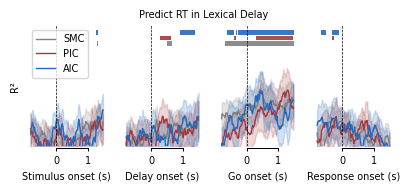

In [ ]:
sig = rt_subset[rt_subset['mask'] == True].copy()

# 按 channel 分组，检查每个 channel 是否至少有一个显著时间点 (mask == True)
sig_channels = sig.groupby('channel').size() > 0
sig_channels = sig_channels[sig_channels].index.tolist()

sig_rt = rt_subset[
    rt_subset['channel'].isin(sig_channels)
].copy()

rois = ['SMC','PIC','AIC']
palette=['gray', red, blue]

# rois = sig.roi.unique()
condition = 'Repeat'
subset = sig_rt[(sig_rt.description==condition)]

plt.subplots_adjust(wspace=0)

ymax, pad, bar_h = 0.2, 0.01, 0.01
sig_threshold = 0.15  # 1%

phases = ['Stimulus', 'Delay' ,'Go', 'Response']

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*len(phases)*cm, 4*cm))

for (ax, phase) in zip(axes, phases):
    
    # only add the legend to the first axis
    legend = False if ax != fig.axes[0] else True

    g = subset[(subset.phase == phase) & (subset.roi.isin(rois))].groupby('channel')['r2']

    picks = (
        g.min().ge(-1) &   
        g.max().le(1) &    
        g.max().gt(0)     
    )
    
    picks = picks[picks].index
    palette_map = dict(zip(rois, palette))

    line = sns.lineplot(
        data=subset[(subset.phase == phase) & (subset.channel.isin(picks))],
        x='time',
        y='r2',
        ax=ax,
        legend=legend,
        hue='roi',
        hue_order=rois,
        palette=palette,
        lw=1
    )

    ylabel = 'R²' if ax == axes[0] else ''
    ax.set_ylabel(ylabel, fontsize=7)
    ax.set_xlabel(f'{phase} onset (s)', fontsize=7)   
        
    ymin = 0
    bar_base = ymax + pad
    gap = bar_h * 0.1 
    
    for i, roi in enumerate(rois):
        sig_ratio = subset[(subset.phase == phase) & (subset.roi == roi)].sort_values('time')
        sig_ratio = sig_ratio.groupby('time')['mask'].mean()
        aggregated_mask = sig_ratio >= sig_threshold
    
        if aggregated_mask.any():
            y0 = bar_base + i * (bar_h + gap)
            ax.fill_between(
                sig_ratio.index.values,
                y0,
                y0 + bar_h,
                where=aggregated_mask.values,
                color=palette_map[roi],
                alpha=0.9,
                step='mid',
                linewidth=0
            )
    
    # 让 ylim 包含所有 bar
    ax.set_ylim(ymin, bar_base + len(rois) * (bar_h + gap) + bar_h)

for ax in fig.axes:
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    # ax.axhline(y=-0.1, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    # ax.set_ylim(ymin, ymax + pad + bar_h + 0.02)

plt.suptitle(f'Predict RT in Lexical Delay', fontsize=7)
# plt.savefig(f'../img/misc/fig5_predict_rt_temporal_ROI.svg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
rt.loc[rt['mask'], 'channel'].unique()

array(['D0023_RMSF10-11', 'D0023_RMSF9-10', 'D0023_RPSF12-13', ...,
       'D0137_LTPM1-2', 'D0137_LTMM2-3', 'D0137_LTAM4-5'], dtype=object)

In [ ]:
# 1. 筛选 significant 的电极
sig_channels = rt_subset.loc[rt_subset['mask'], 'channel'].unique()
sig_rt = rt_subset[rt_subset['channel'].isin(sig_channels)].copy()

# 2. 只看 Go phase + Repeat description
# subset = sig_rt[(sig_rt.description=='Repeat') & (sig_rt.phase=='Go')].copy()

delay_mask = (
    (rt['phase'] == 'Delay') &
    (rt['time'] >= 0.0) &
    (rt['time'] <= 1) &
    (rt['mask'] == True)
)
 
# Go 窗口 [-0.5, 0]
go_mask = (
    (rt['phase'] == 'Go') &
    (rt['time'] >= -1) &
    (rt['time'] <= 0.0) &
    (rt['mask'] == True)
)

sig_channels = np.union1d(
    rt.loc[delay_mask, 'channel'].unique(),
    rt.loc[go_mask, 'channel'].unique()
)

subset = sig_rt[sig_rt['channel'].isin(sig_channels)].copy()
# 3. 筛选动态范围在 [-1, 1] 且 max > 0 的电极
g = subset.groupby('channel')['r2']

picks = (
    g.min().ge(-1) &   
    g.max().le(1) &    
    g.max().gt(0)      
)
picks = picks[picks].index  

print(f"原始 significant 电极数: {len(sig_channels)}")
print(f"phase 中满足条件的电极数: {len(picks)}")

# 只保留满足条件的电极
subset = subset[subset.channel.isin(picks)].copy()

# 聚合坐标信息
coords_ = subset.groupby('channel').agg({
    'r2': 'max',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
}).reset_index()

coords_ = coords_[coords_['r2'] > 0.1]

# 验证筛选结果
print("\n筛选后的 R² 统计:")
print(f"  Min: {subset['r2'].min():.4f}")
print(f"  Max: {subset['r2'].max():.4f}")
print(f"  每个 channel 的 max:")
channel_max = subset.groupby('channel')['r2'].max()
print(f"    所有 channel 的 max 都 > 0: {(channel_max > 0).all()}")
print(f"    Max 的范围: [{channel_max.min():.4f}, {channel_max.max():.4f}]")

coords_.head()

原始 significant 电极数: 753
phase 中满足条件的电极数: 613

筛选后的 R² 统计:
  Min: -0.9198
  Max: 0.8929
  每个 channel 的 max:
    所有 channel 的 max 都 > 0: True
    Max 的范围: [0.1864, 0.8929]


,channel,r2,x,y,z,roi,label,phase,hemi,subject
0,D0019_RMOS3-4,0.247319,16.024804,-56.288230,68.934555,SPL,ctx_rh_G_parietal_sup,Delay,R,D0019
1,D0022_LPIF4-5,0.234268,-40.742572,-20.437126,-4.055261,PIC,ctx_lh_S_circular_insula_inf,Delay,L,D0022
2,D0023_R2IF1-2,0.328770,33.089530,-8.192050,18.614382,PIC,ctx_rh_S_circular_insula_sup,Delay,R,D0023
3,D0023_R2MF10-11,0.554090,40.025482,-8.423863,36.077959,SMC,ctx_rh_S_precentral-inf-part,Delay,R,D0023
4,D0023_R2MF9-10,0.413007,36.417728,-8.358371,36.078040,SMC,ctx_rh_S_precentral-inf-part,Delay,R,D0023


2026-03-30 20:14:38.243 ( 125.180s) [    7FA9987FA740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


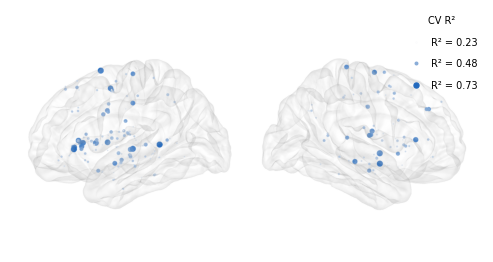

In [ ]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree


roi_list = ['AIC','SMC','PIC','SFG','MFG','STS','IFG']
coords = coords_[coords_.roi.isin(roi_list)][['x','y','z']].values
vals = coords_[coords_.roi.isin(roi_list)]['r2'].values

vmin = np.nanpercentile(vals, 2)
vmax = np.nanpercentile(vals, 98)

if not np.isfinite(vmin):
    vmin = np.nanmin(vals)
if not np.isfinite(vmax):
    vmax = np.nanmax(vals)
if vmin == vmax:
    vmax = vmin + 1e-6

cmap = blues
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

sizes = 5 + 30 * np.clip((vals - vmin) / (vmax - vmin), 0, 1)
# sizes = np.ones_like(vals) * 30

lh_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_coords)
rh_tree = cKDTree(rh_coords)

lh = Brain('fsaverage', subjects_dir=recon_dir, hemi='lh', surf='pial', background='white', show=False, cortex=(0.9,0.9,0.9), alpha=0.15, size=(600*cm, 600*cm))
rh = Brain('fsaverage', subjects_dir=recon_dir, hemi='rh', surf='pial', background='white', show=False, cortex=(0.9,0.9,0.9), alpha=0.15, size=(600*cm, 600*cm))

mask_lh = coords[:, 0] < 0
mask_rh = coords[:, 0] > 0

if mask_lh.any():
    _, idx = lh_tree.query(coords[mask_lh])
    proj = lh_coords[idx]
    for pt, v, s in zip(proj, vals[mask_lh], sizes[mask_lh]):
        lh._renderer.plotter.add_mesh(pv.PolyData(pt.reshape(1,3)), render_points_as_spheres=True, point_size=float(s), color=cmap(norm(v))[:3], lighting=False, opacity=0.95)

if mask_rh.any():
    _, idx = rh_tree.query(coords[mask_rh])
    proj = rh_coords[idx]
    for pt, v, s in zip(proj, vals[mask_rh], sizes[mask_rh]):
        rh._renderer.plotter.add_mesh(pv.PolyData(pt.reshape(1,3)), render_points_as_spheres=True, point_size=float(s), color=cmap(norm(v))[:3], lighting=False, opacity=0.95)

for b in (lh, rh):
    b.show_view(view='lateral', distance=400)
    b._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1]})
plt.subplots_adjust(wspace=-0.1)
ax1.imshow(lh.screenshot(mode='rgb'))
ax1.axis('off')
ax2.imshow(rh.screenshot(mode='rgb'))
ax2.axis('off')

# 添加图例 - 修复大小不一致问题
from matplotlib.lines import Line2D

# 创建示例 R² 值
example_r2 = [vmin, (vmin + vmax) / 2, vmax]
example_labels = [f'{vmin:.2f}', f'{(vmin + vmax) / 2:.2f}', f'{vmax:.2f}']

# 计算对应的大小（和脑图完全一致）
example_sizes = 1 + 35 * np.clip((np.array(example_r2) - vmin) / (vmax - vmin), 0, 1)

# 创建图例句柄 - 使用缩放因子匹配 PyVista 大小
handles = []
for r2_val, size, label in zip(example_r2, example_sizes, example_labels):
    # 调整缩放因子让 matplotlib markersize 匹配 PyVista point_size
    # 通过实验找到合适的缩放因子
    markersize = size * 0.1  # 调整这个因子来匹配脑图中的大小
    
    handle = Line2D(
        [0], [0], 
        marker='o', 
        linestyle='None',
        markerfacecolor=cmap(norm(r2_val)),
        markeredgecolor=cmap(norm(r2_val)),
        markersize=markersize,
        label=f'R² = {label}'
    )
    handles.append(handle)

# 添加图例到右侧图
ax2.legend(
    handles=handles,
    title='CV R²',
    loc='upper right',
    frameon=False,
    borderaxespad=0.2,
    handletextpad=0.6,
    labelspacing=1.2,
    fontsize=7,
    title_fontsize=7
)

lh.close()
rh.close()

# fig.savefig(f'../img/misc/fig5_spatial_delay.svg', dpi=300, bbox_inches='tight')

Most electrodes ROI: STS (n=58)


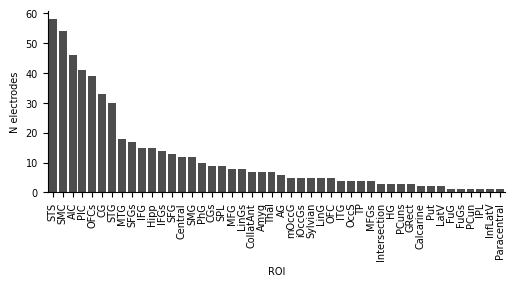

,roi,n_electrodes
40,STS,58
36,SMC,54
1,AIC,46
30,PIC,41
26,OFCs,39
3,CG,33
39,STG,30
24,MTG,18
35,SFGs,17
13,IFG,15


In [ ]:
roi_counts = (
    coords_[['roi', 'channel']]
    # .loc[coords_.hemi=='L']
    .dropna(subset=['roi', 'channel'])
    .drop_duplicates()
    .groupby('roi', as_index=False)
    .agg(n_electrodes=('channel', 'nunique'))
    .sort_values('n_electrodes', ascending=False)
)

max_roi = roi_counts.iloc[0]['roi']
max_n = int(roi_counts.iloc[0]['n_electrodes'])
print(f"Most electrodes ROI: {max_roi} (n={max_n})")

top_n = 10
roi_counts_plot = roi_counts.head(top_n)

fig, ax = plt.subplots(figsize=(15*cm, 6*cm))
ax = sns.barplot(
    data=roi_counts,
    x='roi',
    y='n_electrodes',
    order=roi_counts['roi'],
    color='0.3',
)
ax.set_xlabel('ROI', fontdict=fontdict)
ax.set_ylabel('N electrodes', fontdict=fontdict)
ax.tick_params(axis='x', rotation=90, labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)
sns.despine()
# plt.tight_layout()
plt.show()

# fig.savefig('../img/fig4/fig4_RT_roi_counts.svg', dpi=300, bbox_inches='tight')
roi_counts.head(10)

       roi  n_electrodes
0      SMC            47
1      STS            42
2      AIC            37
3      PIC            36
4     OFCs            30
5       CG            27
6      STG            25
7      MTG            13
8     Hipp            12
9     IFGs            12
10  OTHERS           161


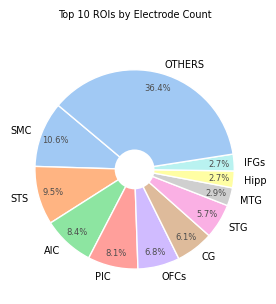

In [ ]:
# --- 1. 处理数据：保留 Top N，其余归为 OTHERS ---
top_n = 10
roi_counts_sorted = roi_counts.sort_values('n_electrodes', ascending=False)

# 取出前 N 个
roi_counts_top = roi_counts_sorted.iloc[:top_n].copy()

# 计算剩余的总和
others_count = roi_counts_sorted.iloc[top_n:]['n_electrodes'].sum()

# 构造 OTHERS 行并合并
others_row = pd.DataFrame({'roi': ['OTHERS'], 'n_electrodes': [others_count]})
plot_df = pd.concat([roi_counts_top, others_row], ignore_index=True)

# --- 2. 绘制饼图 ---
fig, ax = plt.subplots(figsize=(8*cm, 8*cm))

# 使用调色盘
colors = sns.color_palette('pastel', n_colors=len(plot_df))

# 绘制
wedges, texts, autotexts = ax.pie(
    plot_df['n_electrodes'], 
    labels=plot_df['roi'], 
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.85,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

# 调整字体大小
plt.setp(texts, size=fontsize)
plt.setp(autotexts, size=fontsize-1, color='0.3')

# 添加中间的白色圆圈使其变成 Donut Chart（更现代一点）
centre_circle = plt.Circle((0,0), 0.20, fc='white')
fig.gca().add_artist(centre_circle)

# 设置标题
plt.title(f'Top {top_n} ROIs by Electrode Count', fontsize=fontsize, pad=20)

plt.tight_layout()

# plt.savefig('../img/misc/top_10_pie_chart_delay.svg', dpi=300, bbox_inches='tight')

# 打印表格核对数据
print(plot_df)

# Comparsion

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 统一时间/列名
rt['time'] = pd.to_numeric(rt['time'], errors='coerce')
score_col = 'score' if 'score' in rt.columns else 'r2'

# 只看 AIC / SMC
rt_roi = rt[rt['roi'].isin(['AIC', 'SMC'])].copy()

# 定义两个窗口
delay_win = (rt_roi['phase'] == 'Delay') & (rt_roi['time'] >= 0.0) & (rt_roi['time'] <= 0.5)
go_after_win = (rt_roi['phase'] == 'Go') & (rt_roi['time'] > 0.0) & (rt_roi['time'] <= 0.5)  # 如需上限可加 <=0.5

# 取显著点
delay_sig = rt_roi[delay_win & rt_roi['mask']]
go_sig = rt_roi[go_after_win & rt_roi['mask']]

# 总电极数（按 ROI 去重）
total_by_roi = rt_roi.groupby('roi')['channel'].nunique().rename('n_total')

def summarize_window(df_sig, label):
    # 每个电极的最大 score & 首次显著时间
    ch_max = df_sig.groupby(['roi','channel'])[score_col].max().rename('max_score').reset_index()
    ch_first_t = (
        df_sig.groupby(['roi','channel'])['time']
        .min()
        .rename('first_sig_time')
        .reset_index()
    )
    ch_summary = ch_max.merge(ch_first_t, on=['roi','channel'])
    # 计数
    counts = df_sig.groupby('roi')['channel'].nunique().rename('n_sig').reset_index()
    counts['window'] = label
    counts = counts.merge(total_by_roi.reset_index(), on='roi', how='left')
    counts['proportion'] = counts['n_sig'] / counts['n_total']
    ch_summary['window'] = label
    return counts, ch_summary

delay_counts, delay_ch_summary = summarize_window(delay_sig, 'Delay[0,0.5]')
go_counts, go_ch_summary = summarize_window(go_sig, 'Go(>0)')

counts_all = pd.concat([delay_counts, go_counts], ignore_index=True)
ch_summary_all = pd.concat([delay_ch_summary, go_ch_summary], ignore_index=True)

print("Counts / proportion by ROI x window:")
display(counts_all)

# 画比例柱状图
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(data=counts_all, x='roi', y='proportion', hue='window', ax=ax)
ax.set_ylabel('Proportion of electrodes (sig)')
ax.set_xlabel('ROI')
sns.despine()
plt.show()

# 画 max score 分布
fig, ax = plt.subplots(figsize=(6,4))
sns.violinplot(data=ch_summary_all, x='roi', y='max_score', hue='window', split=True, inner='quartile', ax=ax)
ax.set_ylabel(f'Max {score_col}')
ax.set_xlabel('ROI')
sns.despine()
plt.show()

# 画首次显著时间分布
fig, ax = plt.subplots(figsize=(6,4))
sns.violinplot(data=ch_summary_all, x='roi', y='first_sig_time', hue='window', split=True, inner='quartile', ax=ax)
ax.set_ylabel('First significant time (s)')
ax.set_xlabel('ROI')
sns.despine()
plt.show()

KeyError: 'roi'